## Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

%pip install -q "pandas==2.2.2" "malariagen_data>=15,<16" scikit-allel

import os
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import malariagen_data

# Saving
OUTPUT_DIR = "/content/drive/MyDrive/FYP/exploratory_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
for folder in [TABLE_DIR, FIGURE_DIR]:
    os.makedirs(folder, exist_ok=True)

ag3 = malariagen_data.Ag3(check_location=False)
metadata = ag3.sample_metadata()

print("Metadata rows:", len(metadata))

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.2/265.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

## Metadata summaries

In [ ]:
# First look at the available samples for both species.
female_samples = metadata[
    metadata["sex_call"].eq("F") &
    metadata["taxon"].isin(["coluzzii", "gambiae"])
].copy()

summary_by_country = (
    female_samples
    .groupby(["taxon", "country", "year"], dropna=False)
    .size()
    .reset_index(name="N_individuals")
    .sort_values(["taxon", "country", "year"])
)

display(summary_by_country)
summary_by_country.to_csv(
    os.path.join(TABLE_DIR, "metadata_summary_by_country_year.csv"),
    index=False,
)

,taxon,country,year,N_individuals
0,coluzzii,Angola,2009,77
1,coluzzii,Angola,2010,8
2,coluzzii,Benin,2014,6
3,coluzzii,Benin,2017,166
4,coluzzii,Benin,2018,380
...,...,...,...,...
163,gambiae,Uganda,2019,377
164,gambiae,Zambia,2015,6
165,gambiae,Zambia,2018,12
166,gambiae,Zambia,2020,113


In [ ]:
# A more detailed table helped with choosing locations and checking sample size.
columns = [
    "taxon", "country", "location", "year", "month",
    "contributor", "sex_call"
]
columns = [c for c in columns if c in metadata.columns]

detailed_summary = (
    metadata[metadata["sex_call"].eq("F")]
    .groupby(columns, dropna=False)
    .size()
    .reset_index(name="N_individuals")
)

display(detailed_summary.head(30))
detailed_summary.to_csv(
    os.path.join(TABLE_DIR, "metadata_summary_by_location.csv"),
    index=False,
)

,taxon,country,location,year,month,contributor,sex_call,N_individuals
0,arabiensis,Burkina Faso,Bana,2014,7,Austin Burt,F,1
1,arabiensis,Burkina Faso,Bana Village,2017,8,Mahamadi Kientega,F,1
2,arabiensis,Burkina Faso,Bana Village,2017,10,Mahamadi Kientega,F,1
3,arabiensis,Burkina Faso,Bana Village,2019,8,Mahamadi Kientega,F,1
4,arabiensis,Burkina Faso,Gama,2022,10,Abdoulaye Diabate,F,3
5,arabiensis,Burkina Faso,Gama,2022,11,Abdoulaye Diabate,F,10
6,arabiensis,Burkina Faso,Goundry,2008,11,Jacob E Crawford,F,2
7,arabiensis,Burkina Faso,Kodougou,2008,11,Jacob E Crawford,F,1
8,arabiensis,Burkina Faso,Monomtenga-B,2004,-1,Michael.C.Fontaine,F,4
9,arabiensis,Burkina Faso,Nagare,2022,10,Abdoulaye Diabate,F,9


## Exploratory populations

In [ ]:
# These were the four populations used during the earlier exploratory work.
# The final thesis later used a different Nigeria and Burkina Faso cohort.
selected_locations = pd.DataFrame([
    {"Population_ID": "BurkinaFaso_OuroHesso", "Short_ID": "BF",
     "Country": "Burkina Faso", "Location": "Ouro-Hesso"},
    {"Population_ID": "Guinea_SiguiriDankakoro", "Short_ID": "GN",
     "Country": "Guinea", "Location": "Siguiri_Dankakoro"},
    {"Population_ID": "Mali_Faladje", "Short_ID": "ML",
     "Country": "Mali", "Location": "Faladje"},
    {"Population_ID": "Nigeria_Katcha", "Short_ID": "NG",
     "Country": "Nigeria", "Location": "Katcha"},
])

population_rows = []

for _, pop in selected_locations.iterrows():
    query = (
        "taxon == 'coluzzii' and year == 2022 and sex_call == 'F' "
        f"and country == {repr(pop['Country'])} "
        f"and location == {repr(pop['Location'])}"
    )

    samples = metadata.query(query)

    population_rows.append({
        **pop.to_dict(),
        "N_individuals": len(samples),
        "Latitude": samples["latitude"].iloc[0] if len(samples) else np.nan,
        "Longitude": samples["longitude"].iloc[0] if len(samples) else np.nan,
        "Sample_query": query,
    })

populations = pd.DataFrame(population_rows)
display(populations)

populations.to_csv(
    os.path.join(TABLE_DIR, "exploratory_populations.csv"),
    index=False,
)

,Population_ID,Short_ID,Country,Location,N_individuals,Latitude,Longitude,Sample_query
0,BurkinaFaso_OuroHesso,BF,Burkina Faso,Ouro-Hesso,61,14.375,-0.128,taxon == 'coluzzii' and year == 2022 and sex_c...
1,Guinea_SiguiriDankakoro,GN,Guinea,Siguiri_Dankakoro,81,11.416,-9.058,taxon == 'coluzzii' and year == 2022 and sex_c...
2,Mali_Faladje,ML,Mali,Faladje,75,13.137,-8.338,taxon == 'coluzzii' and year == 2022 and sex_c...
3,Nigeria_Katcha,NG,Nigeria,Katcha,50,9.095,6.212,taxon == 'coluzzii' and year == 2022 and sex_c...


## Distance from the centromere and population pairs

In [ ]:
# The coordinate stored here is the end of the chromosome arm next to the centromere.
ARM_ENDS = {"3R": 53_200_684, "X": 24_393_108}

def region_from_centromere(contig, distance_start, distance_end):
    arm_end = ARM_ENDS[contig]
    genomic_start = arm_end - distance_end + 1
    genomic_end = arm_end - distance_start + 1
    return f"{contig}:{genomic_start}-{genomic_end}"

def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(
        math.radians, [lat1, lon1, lat2, lon2]
    )
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        math.sin(dlat / 2) ** 2 +
        math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )
    return 2 * r * math.asin(math.sqrt(a))

pair_rows = []

for i, j in itertools.combinations(populations.index, 2):
    p1 = populations.loc[i]
    p2 = populations.loc[j]

    pair_rows.append({
        "Pair_ID": f"{p1['Population_ID']}_vs_{p2['Population_ID']}",
        "Pair_short": f"{p1['Short_ID']}-{p2['Short_ID']}",
        "Population_1": p1["Population_ID"],
        "Population_2": p2["Population_ID"],
        "Cohort1_query": p1["Sample_query"],
        "Cohort2_query": p2["Sample_query"],
        "Involves_Nigeria": (
            p1["Country"] == "Nigeria" or p2["Country"] == "Nigeria"
        ),
        "Geographic_distance_km": haversine_km(
            p1["Latitude"], p1["Longitude"],
            p2["Latitude"], p2["Longitude"],
        ),
    })

pairs = pd.DataFrame(pair_rows)
display(pairs[[
    "Pair_short", "Involves_Nigeria", "Geographic_distance_km"
]])

,Pair_short,Involves_Nigeria,Geographic_distance_km
0,BF-GN,False,1022.156688
1,BF-ML,False,897.284725
2,BF-NG,True,905.940779
3,GN-ML,False,206.737674
4,GN-NG,True,1690.354280
5,ML-NG,True,1649.421462


## Site classes and FST helper

In [ ]:
# 0-fold in black and 4-fold in red
SITE_CLASSES = {
    "0-fold": {"argument": "CDS_DEG_0", "color": "black"},
    "4-fold": {"argument": "CDS_DEG_4", "color": "red"},
}

def run_fst(region, query1, query2, site_class, n_jack=20):
    try:
        fst, se = ag3.average_fst(
            region=region,
            cohort1_query=query1,
            cohort2_query=query2,
            site_mask="default",
            site_class=site_class,
            min_cohort_size=15,
            max_cohort_size=None,
            n_jack=n_jack,
            random_seed=42,
        )
        return float(fst), float(se), "success", ""
    except Exception as error:
        print("FST failed:", region, error)
        return np.nan, np.nan, "failed", str(error)

def count_sites(region):
    # This is only used to flag windows with few usable coding sites.
    ann = ag3.site_annotations(region=region, site_mask="default")

    seq_cls = ann["seq_cls"].data.compute()
    codon_position = ann["codon_position"].data.compute()
    codon_degeneracy = ann["codon_degeneracy"].data.compute()

    is_cds = np.isin(seq_cls, [5, 6, 7])
    n_0fold = np.sum(is_cds & (codon_degeneracy == 1))
    n_4fold = np.sum(
        is_cds & (codon_position == 2) & (codon_degeneracy == 4)
    )

    return int(n_0fold), int(n_4fold)


## Matched 1 Mb window at 10–11 Mb from the centromere

In [ ]:
# This answers the early question about one matched 1 Mb window on X and 3R.
matched_windows = pd.DataFrame([
    {
        "Contig": contig,
        "Region": region_from_centromere(
            contig, 10_000_001, 11_000_000
        ),
    }
    for contig in ["3R", "X"]
])

display(matched_windows)

,Contig,Region
0,3R,3R:42200685-43200684
1,X,X:13393109-14393108


In [ ]:
matched_rows = []

for _, pair in pairs.iterrows():
    for _, window in matched_windows.iterrows():
        for site_class, style in SITE_CLASSES.items():

            fst, se, status, error = run_fst(
                window["Region"],
                pair["Cohort1_query"],
                pair["Cohort2_query"],
                style["argument"],
                n_jack=200,
            )

            matched_rows.append({
                "Pair_ID": pair["Pair_ID"],
                "Pair_short": pair["Pair_short"],
                "Involves_Nigeria": pair["Involves_Nigeria"],
                "Contig": window["Contig"],
                "Region": window["Region"],
                "Site_class": site_class,
                "FST": fst,
                "SE": se,
                "Run_status": status,
                "Error_message": error,
            })

matched_fst = pd.DataFrame(matched_rows)

display(matched_fst)

# Show failures separately so a missing chromosome is easy to spot.
failed = matched_fst[matched_fst["Run_status"].ne("success")]
if len(failed):
    display(failed[[
        "Pair_short", "Contig", "Region",
        "Site_class", "Error_message"
    ]])

matched_fst.to_csv(
    os.path.join(TABLE_DIR, "matched_1Mb_window_FST.csv"),
    index=False,
)


Access SNP calls: ⠇ (0:00:33.26)

Locate CDS_DEG_0 sites:   0%|          | 0/6 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/49 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/65 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/allel/stats/fst.py:753: RuntimeWarning: invalid value encountered in divide
  vb = num_bsum / den_bsum


...

Compute SNP allele counts:   0%|          | 0/77 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/147 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/77 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/147 [00:00<?, ?it/s]

,Pair_ID,Pair_short,Involves_Nigeria,Contig,Region,Site_class,FST,SE,Run_status,Error_message
0,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,False,3R,3R:42200685-43200684,0-fold,0.000000,0.000733,success,
1,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,False,3R,3R:42200685-43200684,4-fold,0.000000,0.000685,success,
2,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,False,X,X:13393109-14393108,0-fold,0.000000,0.000516,success,
3,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,False,X,X:13393109-14393108,4-fold,0.000000,0.000370,success,
4,BurkinaFaso_OuroHesso_vs_Mali_Faladje,BF-ML,False,3R,3R:42200685-43200684,0-fold,0.000000,0.000615,success,
5,BurkinaFaso_OuroHesso_vs_Mali_Faladje,BF-ML,False,3R,3R:42200685-43200684,4-fold,0.000218,0.000786,success,
6,BurkinaFaso_OuroHesso_vs_Mali_Faladje,BF-ML,False,X,X:13393109-14393108,0-fold,0.000000,0.000621,success,
7,BurkinaFaso_OuroHesso_vs_Mali_Faladje,BF-ML,False,X,X:13393109-14393108,4-fold,0.000365,0.000557,success,
8,BurkinaFaso_OuroHesso_vs_Nigeria_Katcha,BF-NG,True,3R,3R:42200685-43200684,0-fold,0.001345,0.000855,success,
9,BurkinaFaso_OuroHesso_vs_Nigeria_Katcha,BF-NG,True,3R,3R:42200685-43200684,4-fold,0.002283,0.000838,success,


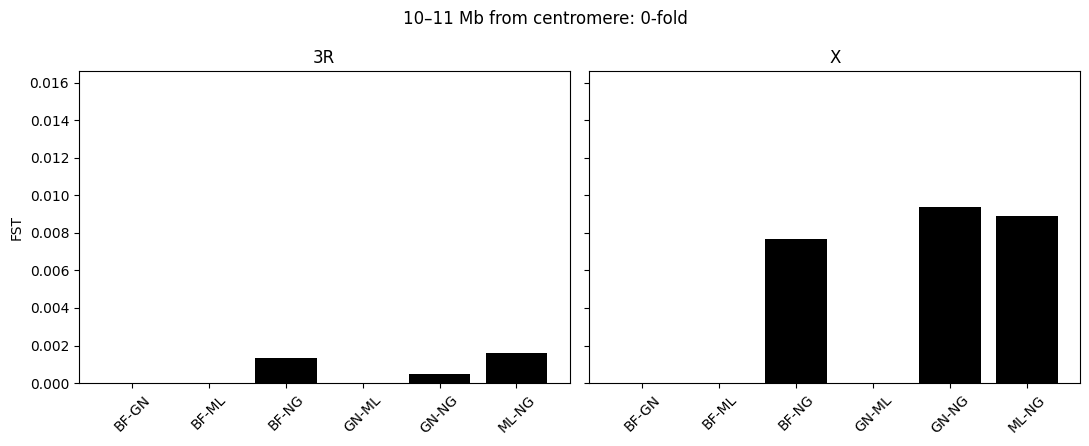

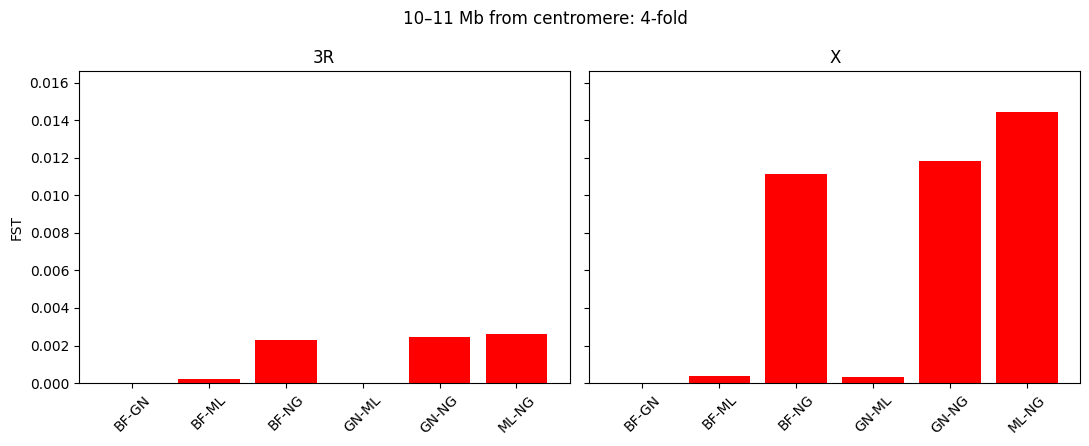

In [ ]:
# Plot X and 3R on the same y-axis and without error bars.
plot_data = matched_fst[
    matched_fst["Run_status"].eq("success")
].copy()

if plot_data.empty:
    print("No successful FST results are available yet.")
else:
    ymax = max(plot_data["FST"].max() * 1.15, 0.001)

    for site_class, style in SITE_CLASSES.items():
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

        for ax, contig in zip(axes, ["3R", "X"]):
            sub = plot_data[
                plot_data["Site_class"].eq(site_class) &
                plot_data["Contig"].eq(contig)
            ]

            if len(sub):
                ax.bar(
                    sub["Pair_short"],
                    sub["FST"],
                    color=style["color"],
                )
            else:
                ax.text(
                    0.5, 0.5,
                    "No successful results",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )

            ax.set_title(contig)
            ax.set_ylim(0, ymax)
            ax.tick_params(axis="x", rotation=45)

        axes[0].set_ylabel("FST")
        fig.suptitle(f"10–11 Mb from centromere: {site_class}")
        fig.tight_layout()

        fig.savefig(
            os.path.join(
                FIGURE_DIR,
                f"matched_1Mb_{site_class.replace('-', '')}.png"
            ),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


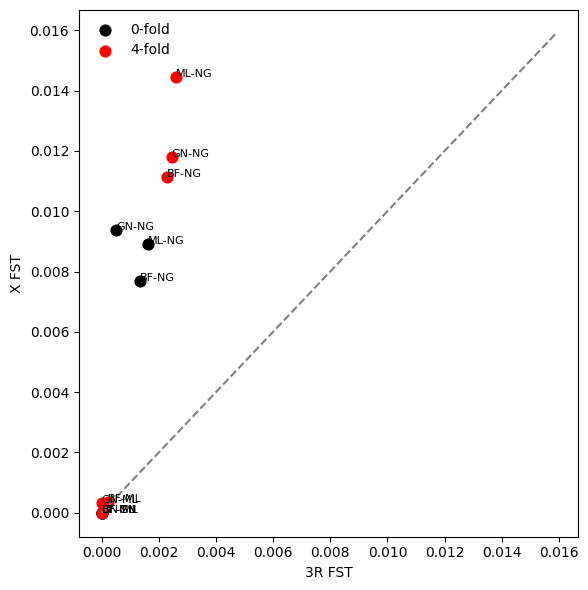

In [ ]:
# Compare the matched X and 3R values directly.
matched_wide = (
    plot_data
    .pivot_table(
        index=["Pair_short", "Site_class"],
        columns="Contig",
        values="FST",
    )
    .reindex(columns=["3R", "X"])
    .reset_index()
)

complete_pairs = matched_wide.dropna(subset=["3R", "X"]).copy()

if complete_pairs.empty:
    print(
        "No pair has successful FST values for both X and 3R. "
        "Check the failed rows from the previous cell."
    )
else:
    fig, ax = plt.subplots(figsize=(6, 6))

    for site_class, style in SITE_CLASSES.items():
        sub = complete_pairs[
            complete_pairs["Site_class"].eq(site_class)
        ]

        ax.scatter(
            sub["3R"],
            sub["X"],
            color=style["color"],
            label=site_class,
            s=60,
        )

        for _, row in sub.iterrows():
            ax.text(
                row["3R"],
                row["X"],
                row["Pair_short"],
                fontsize=8,
            )

    limit = np.nanmax(
        complete_pairs[["3R", "X"]].to_numpy()
    ) * 1.1

    if limit <= 0:
        limit = 0.001

    ax.plot([0, limit], [0, limit], "--", color="grey")
    ax.set_xlabel("3R FST")
    ax.set_ylabel("X FST")
    ax.legend(frameon=False)
    fig.tight_layout()

    fig.savefig(
        os.path.join(FIGURE_DIR, "matched_1Mb_X_vs_3R.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 1 Mb scans along the first 25 Mb from the centromere

In [ ]:
# X is shorter, so only complete 1 Mb windows are kept.
window_rows = []

for contig in ["3R", "X"]:
    for start in range(0, 25_000_000, 1_000_000):
        end = start + 1_000_000

        genomic_start = ARM_ENDS[contig] - end + 1
        genomic_end = ARM_ENDS[contig] - start

        if genomic_start < 1:
            continue

        window_rows.append({
            "Contig": contig,
            "Distance_start": start,
            "Distance_end": end,
            "Distance_midpoint_Mb": (start + end) / 2 / 1e6,
            "Region": f"{contig}:{genomic_start}-{genomic_end}",
        })

scan_windows = pd.DataFrame(window_rows)

site_rows = []
for _, window in scan_windows.iterrows():
    n0, n4 = count_sites(window["Region"])
    site_rows.append({
        "Region": window["Region"],
        "N_0fold_sites": n0,
        "N_4fold_sites": n4,
    })

site_counts = pd.DataFrame(site_rows)
scan_windows = scan_windows.merge(site_counts, on="Region")

display(scan_windows.head())
scan_windows.to_csv(
    os.path.join(TABLE_DIR, "exploratory_scan_windows_and_site_counts.csv"),
    index=False,
)

,Contig,Distance_start,Distance_end,Distance_midpoint_Mb,Region,N_0fold_sites,N_4fold_sites
0,3R,0,1000000,0.5,3R:52200685-53200684,11296,2594
1,3R,1000000,2000000,1.5,3R:51200685-52200684,53535,13121
2,3R,2000000,3000000,2.5,3R:50200685-51200684,34569,8386
3,3R,3000000,4000000,3.5,3R:49200685-50200684,43712,10742
4,3R,4000000,5000000,4.5,3R:48200685-49200684,46164,11478


In [ ]:
# This scan can take a long time.
# A checkpoint is saved after every calculation so Colab can be restarted safely.
CHECKPOINT = os.path.join(TABLE_DIR, "exploratory_1Mb_scan_checkpoint.csv")
JOBS_PER_RUN = 30

if os.path.exists(CHECKPOINT):
    scan_fst = pd.read_csv(CHECKPOINT)
else:
    scan_fst = pd.DataFrame()

if len(scan_fst):
    done = set(zip(
        scan_fst["Pair_ID"],
        scan_fst["Region"],
        scan_fst["Site_class"],
    ))
else:
    done = set()

new_jobs = 0

for _, pair in pairs.iterrows():
    for _, window in scan_windows.iterrows():
        for site_class, style in SITE_CLASSES.items():

            key = (pair["Pair_ID"], window["Region"], site_class)
            if key in done:
                continue

            if new_jobs >= JOBS_PER_RUN:
                break

            fst, se, status, error = run_fst(
                window["Region"],
                pair["Cohort1_query"],
                pair["Cohort2_query"],
                style["argument"],
                n_jack=20,
            )

            n_sites = (
                window["N_0fold_sites"]
                if site_class == "0-fold"
                else window["N_4fold_sites"]
            )

            row = {
                "Pair_ID": pair["Pair_ID"],
                "Pair_short": pair["Pair_short"],
                "Involves_Nigeria": pair["Involves_Nigeria"],
                "Contig": window["Contig"],
                "Region": window["Region"],
                "Distance_midpoint_Mb": window["Distance_midpoint_Mb"],
                "Site_class": site_class,
                "N_sites": int(n_sites),
                "Low_site_count": int(n_sites) < 1000,
                "FST": fst,
                "SE": se,
                "Run_status": status,
            }

            scan_fst = pd.concat(
                [scan_fst, pd.DataFrame([row])],
                ignore_index=True,
            )
            scan_fst.to_csv(CHECKPOINT, index=False)

            done.add(key)
            new_jobs += 1

        if new_jobs >= JOBS_PER_RUN:
            break
    if new_jobs >= JOBS_PER_RUN:
        break

print("New jobs in this run:", new_jobs)
print("Saved rows:", len(scan_fst))
print("Run this cell again after restarting Colab if more jobs remain.")

Access SNP calls: ⠸ (0:00:05.73)

Locate CDS_DEG_0 sites:   0%|          | 0/7 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/49 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/65 [00:00<?, ?it/s]

Access SNP calls: ⠹ (0:00:09.51)

...

Access SNP calls: ⠴ (0:00:05.88)

Locate CDS_DEG_4 sites:   0%|          | 0/10 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/49 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/65 [00:00<?, ?it/s]

New jobs in this run: 30
Saved rows: 90
Run this cell again after restarting Colab if more jobs remain.


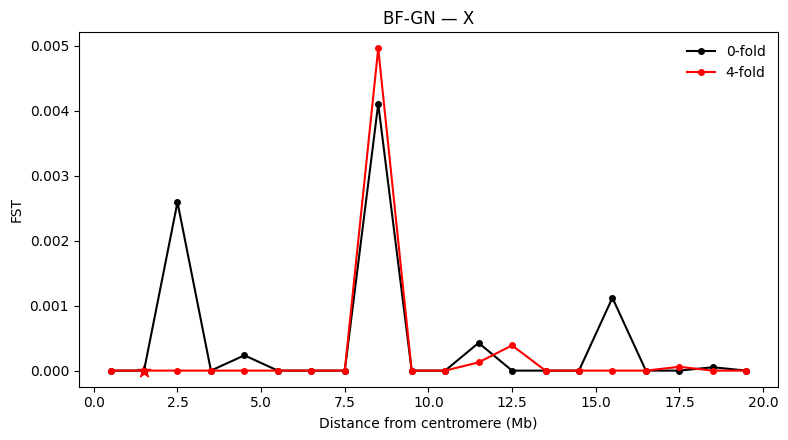

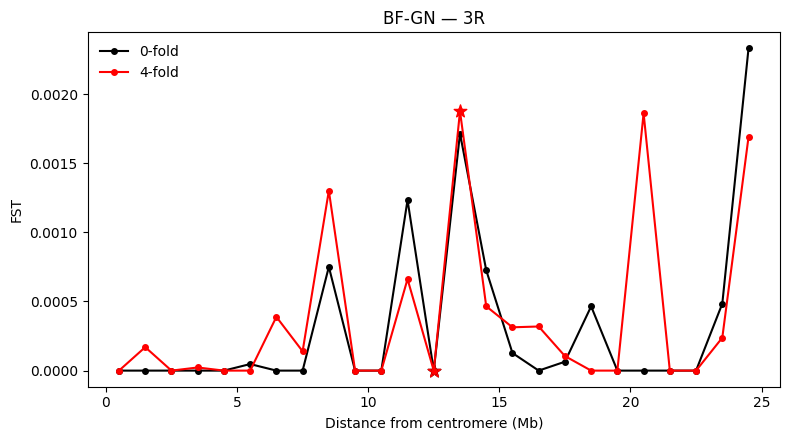

In [ ]:
# Plot the completed part of the scan.
successful = scan_fst[scan_fst["Run_status"].eq("success")].copy()

for pair_id in successful["Pair_ID"].drop_duplicates():
    pair_data = successful[successful["Pair_ID"].eq(pair_id)]
    pair_label = pair_data["Pair_short"].iloc[0]

    for contig in ["X", "3R"]:
        fig, ax = plt.subplots(figsize=(8, 4.5))

        for site_class, style in SITE_CLASSES.items():
            sub = pair_data[
                pair_data["Contig"].eq(contig) &
                pair_data["Site_class"].eq(site_class)
            ].sort_values("Distance_midpoint_Mb")

            ax.plot(
                sub["Distance_midpoint_Mb"],
                sub["FST"],
                marker="o",
                markersize=4,
                color=style["color"],
                label=site_class,
            )

            low = sub[sub["Low_site_count"]]
            ax.scatter(
                low["Distance_midpoint_Mb"],
                low["FST"],
                marker="*",
                s=90,
                color=style["color"],
            )

        ax.set_xlabel("Distance from centromere (Mb)")
        ax.set_ylabel("FST")
        ax.set_title(f"{pair_label} — {contig}")
        ax.legend(frameon=False)
        fig.tight_layout()

        fig.savefig(
            os.path.join(FIGURE_DIR, f"scan_{pair_label}_{contig}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

## First 25 Mb as one large window

In [ ]:
large_windows = pd.DataFrame([
    {
        "Contig": contig,
        "Region": region_from_centromere(
            contig,
            1,
            min(25_000_000, ARM_ENDS[contig]),
        ),
    }
    for contig in ["3R", "X"]
])

large_rows = []

for _, pair in pairs.iterrows():
    for _, window in large_windows.iterrows():
        for site_class, style in SITE_CLASSES.items():

            fst, se, status, error = run_fst(
                window["Region"],
                pair["Cohort1_query"],
                pair["Cohort2_query"],
                style["argument"],
                n_jack=200,
            )

            large_rows.append({
                "Pair_ID": pair["Pair_ID"],
                "Pair_short": pair["Pair_short"],
                "Contig": window["Contig"],
                "Site_class": site_class,
                "FST": fst,
                "SE": se,
                "Run_status": status,
            })

large_fst = pd.DataFrame(large_rows)
display(large_fst)

large_fst.to_csv(
    os.path.join(TABLE_DIR, "first_25Mb_large_window_FST.csv"),
    index=False,
)

Access SNP calls: ⠏ (0:00:20.57)

Locate CDS_DEG_0 sites:   0%|          | 0/120 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/787 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/1049 [00:00<?, ?it/s]

Access SNP calls: ⠹ (0:00:27.48)

...

Compute SNP allele counts:   0%|          | 0/924 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/1900 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/864 [00:00<?, ?it/s]

Compute SNP allele counts:   0%|          | 0/1798 [00:00<?, ?it/s]

,Pair_ID,Pair_short,Contig,Site_class,FST,SE,Run_status
0,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,3R,0-fold,0.000000e+00,0.000158,success
1,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,3R,4-fold,1.389828e-04,0.000132,success
2,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,X,0-fold,0.000000e+00,0.000148,success
3,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,X,4-fold,0.000000e+00,0.000161,success
4,BurkinaFaso_OuroHesso_vs_Mali_Faladje,BF-ML,3R,0-fold,1.156703e-04,0.000190,success
5,BurkinaFaso_OuroHesso_vs_Mali_Faladje,BF-ML,3R,4-fold,1.341095e-04,0.000145,success
6,BurkinaFaso_OuroHesso_vs_Mali_Faladje,BF-ML,X,0-fold,1.421114e-04,0.000184,success
7,BurkinaFaso_OuroHesso_vs_Mali_Faladje,BF-ML,X,4-fold,0.000000e+00,0.000161,success
8,BurkinaFaso_OuroHesso_vs_Nigeria_Katcha,BF-NG,3R,0-fold,4.000852e-03,0.001008,success
9,BurkinaFaso_OuroHesso_vs_Nigeria_Katcha,BF-NG,3R,4-fold,4.458075e-03,0.001118,success


## Simple summaries and tests

In [ ]:
# Means and SE across the available 1 Mb scan windows.
if len(successful):
    scan_summary = (
        successful
        .groupby(["Pair_ID", "Pair_short", "Contig", "Site_class"])
        .agg(
            Mean_FST=("FST", "mean"),
            SE_FST=("FST", "sem"),
            N_windows=("FST", "size"),
        )
        .reset_index()
    )

    display(scan_summary)
    scan_summary.to_csv(
        os.path.join(TABLE_DIR, "exploratory_mean_SE_by_pair.csv"),
        index=False,
    )

    # One simple paired comparison: X versus 3R using pair means.
    wide = scan_summary.pivot_table(
        index=["Pair_ID", "Pair_short", "Site_class"],
        columns="Contig",
        values="Mean_FST",
    ).reindex(columns=["3R", "X"]).reset_index()

    test_rows = []
    for site_class in ["0-fold", "4-fold"]:
        sub = wide[
            wide["Site_class"].eq(site_class)
        ].dropna(subset=["X", "3R"])

        if len(sub):
            stat, p = stats.wilcoxon(sub["X"], sub["3R"])
        else:
            stat, p = np.nan, np.nan

        test_rows.append({
            "Comparison": f"X vs 3R, {site_class}",
            "N_pairs": len(sub),
            "Wilcoxon_statistic": stat,
            "P_value": p,
        })

    tests = pd.DataFrame(test_rows)
    display(tests)
    tests.to_csv(
        os.path.join(TABLE_DIR, "exploratory_simple_tests.csv"),
        index=False,
    )

,Pair_ID,Pair_short,Contig,Site_class,Mean_FST,SE_FST,N_windows
0,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,3R,0-fold,0.000318,0.000122,25
1,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,3R,4-fold,0.000382,0.000123,25
2,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,X,0-fold,0.000427,0.000237,20
3,BurkinaFaso_OuroHesso_vs_Guinea_SiguiriDankakoro,BF-GN,X,4-fold,0.000277,0.000247,20


,Comparison,N_pairs,Wilcoxon_statistic,P_value
0,"X vs 3R, 0-fold",1,0.0,1.0
1,"X vs 3R, 4-fold",1,0.0,1.0
